In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np

def compute_overlap(tmp_path, tmp_path_unpruned, model_name, datasets, fa_approach, threshold=10):

    d_names = {
        "rte":"RTE",
        "arc_challenge":"ARC Challenge",
        "openbookqa":"OpenBookQA",
        "boolq":"BoolQ",
        "arc_easy":"ARC Easy"
    }


    num = 16

    if fa_approach == "lime":
        tmp_fa_approach = "fa_fa"
        plot_fa_name = "LIME"
    else:
        tmp_fa_approach = "fa_kernel_shap"
        plot_fa_name = "Kernel SHAP"
        
        
        
    colors = {"s":"#fc5e03", "c":"#030ffc"}
    for dataset in datasets:
        
        rankings_unpruned = {}

        for i in range(3):
            
            out_file = open(tmp_path_unpruned+model_name+"_"+tmp_fa_approach+"_"+str(i)+".json", "r")
            out = json.load(out_file)
            out_file.close()
            
            for key in out[dataset]:
                if key in rankings_unpruned:
                    rankings_unpruned[key]+= np.array(out[dataset][key])
                else:
                    rankings_unpruned[key]= np.array(out[dataset][key])
                    
        
        rankings_pruned={}    

        for i in range(num):
            rankings_pruned[i]={}

            for j in range(3):
                
                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+tmp_fa_approach+"_"+str(j)+".json", "r")
                out = json.load(out_file)
                out_file.close()
                
                for key in out[dataset]:
                    if out[dataset][key] != "error":
                        if key in rankings_pruned[i]:
                            rankings_pruned[i][key]+= np.array(out[dataset][key])
                        else:
                            rankings_pruned[i][key]= np.array(out[dataset][key])
        
        
        
        
        fig, ax1 = plt.subplots()

        
        for t in [5, 10, 20]:
            overlaps = []
            for key in rankings_pruned:
                overlap = 0
                counter = 0
                for id_text in rankings_unpruned:
                    counter+=1
                    how_many = min(t, len(rankings_unpruned[id_text]))
                    s1 = np.argsort(-rankings_unpruned[id_text])[:how_many]
                    s2 = np.argsort(-rankings_pruned[key][id_text])[:how_many]  
                    overlap +=  len(set(s1).intersection(set(s2)))/how_many
                    
                overlaps.append(overlap/counter)
            
            x_values = list(range(1, len(overlaps) + 1))
            
            lns6 = ax1.plot(x_values, overlaps, label=str(t))
        
        
        
        plt.title(d_names[dataset]+", "+plot_fa_name, fontsize=20)
        plt.xlabel("# removed attention layers", fontsize=18)
        plt.ylabel("Overlap top features", fontsize=18)
        plt.xticks(np.arange(2, 17, 2))
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.ylim(0,1)
        plt.xlim(1,16)

        
        fig.tight_layout()
        plt.savefig("results/plots/overlap/"+dataset+"_"+model_name+"_"+fa_approach+".pdf", dpi=600)
        plt.show()
        
        
        
        

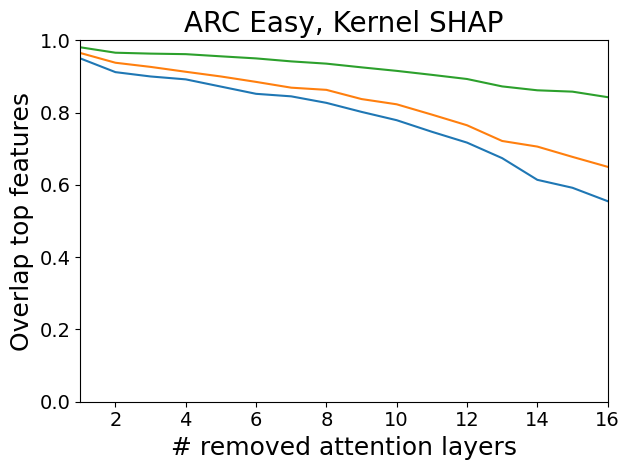

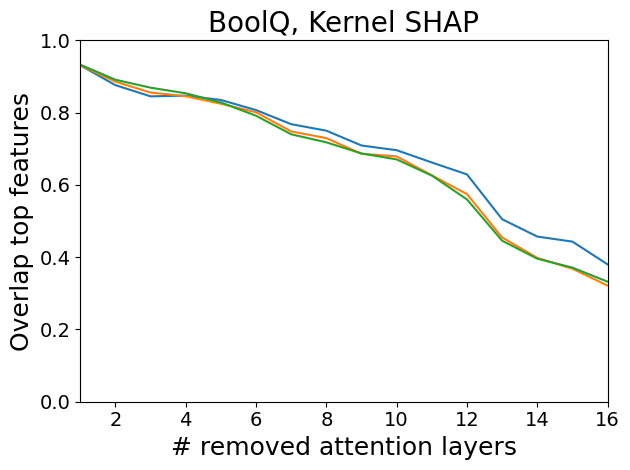

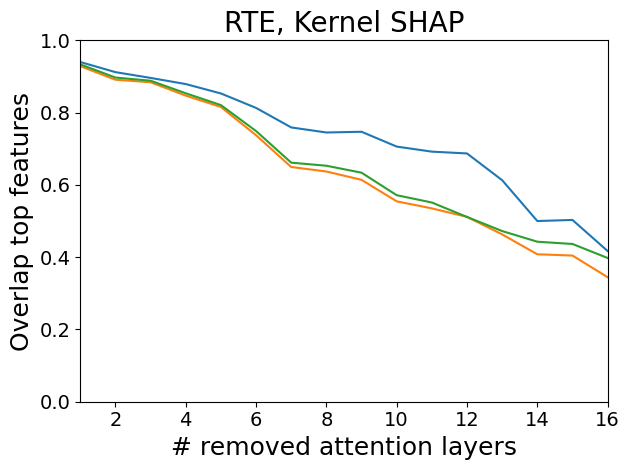

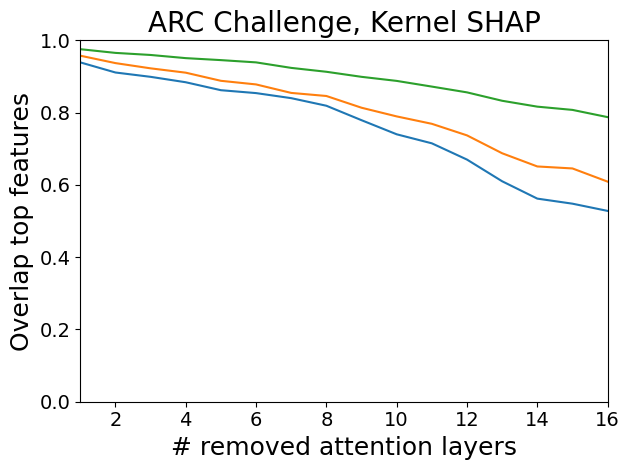

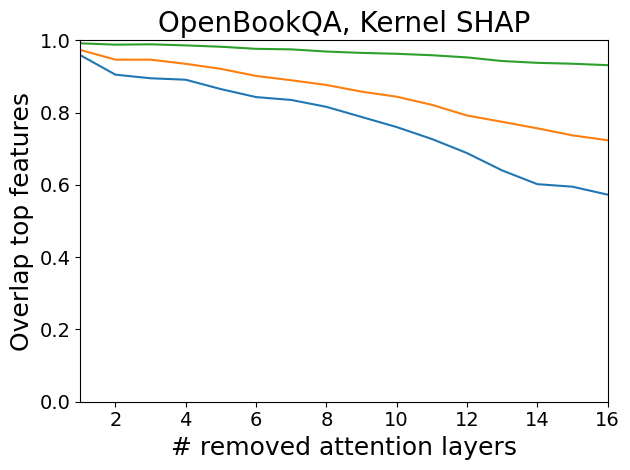

In [9]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "ks"

compute_overlap(tmp_path, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/seeds/mistralai/"
tmp_path_unpruned = "./results/unpruned/seeds/mistralai/"
fa_approach = "lime"

compute_overlap(tmp_path, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path_unpruned =  "./results/unpruned/seeds/meta-llama/"
fa_approach = "lime"

compute_overlap(tmp_path, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/seeds/meta-llama/"
tmp_path_unpruned =  "./results/unpruned/seeds/meta-llama/"
fa_approach = "ks"

compute_overlap(tmp_path, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
import seaborn as sns
import numpy as np
import json
import matplotlib.pyplot as plt

def compute_overlap_heatmap(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach):
    num = 16
    
    d_names = {
    "rte":"RTE",
    "arc_challenge":"ARC Challenge",
    "openbookqa":"OpenBookQA",
    "boolq":"BoolQ",
    "arc_easy":"ARC Easy"
    }


    for model_name, tmp_path, tmp_path2, tmp_path_unpruned in zip(model_names, tmp_paths, tmp_paths2, tmp_paths_unpruned):

        if fa_approach == "lime":
            tmp_fa_approach = "fa_fa"
            plot_fa_name = "LIME"
        else:
            tmp_fa_approach = "fa_kernel_shap"
            plot_fa_name = "Kernel SHAP"

        for dataset in datasets:
            rankings_unpruned = {}
            out_file = open(tmp_path_unpruned + model_name + ".json", "r")
            out = json.load(out_file)
            out_file.close()

            for i in range(3):
                out_file = open(tmp_path_unpruned + model_name + "_" + tmp_fa_approach + "_" + str(i) + ".json", "r")
                out = json.load(out_file)
                out_file.close()

                for key in out[dataset]:
                    if key in rankings_unpruned:
                        rankings_unpruned[key] += np.array(out[dataset][key])
                    else:
                        rankings_unpruned[key] = np.array(out[dataset][key])

            rankings_pruned = [rankings_unpruned]

            for i in range(num):
                pruned_rankings = {}

                for j in range(3):
                    out_file = open(tmp_path + model_name + "_" + str(i) + "_" + tmp_fa_approach + "_" + str(j) + ".json", "r")
                    out = json.load(out_file)
                    out_file.close()

                    for key in out[dataset]:
                        if out[dataset][key] != "error":
                            if key in pruned_rankings:
                                pruned_rankings[key] += np.array(out[dataset][key])
                            else:
                                pruned_rankings[key] = np.array(out[dataset][key])

                rankings_pruned.append(pruned_rankings)

            # Compute overlaps
            overlaps_matrix = []
            
            for i, pruned_ranking in enumerate(rankings_pruned):
                model_overlaps = []
                for j, pruned_ranking2 in enumerate(rankings_pruned):
                    overlap = 0
                    counter = 0
                    
                    
                    for id_text in rankings_unpruned:
                        counter += 1
                        how_many = min(10, len(pruned_ranking2[id_text]), len(pruned_ranking[id_text]))
                        s1 = np.argsort(-pruned_ranking2[id_text])[:how_many]
                        s2 = np.argsort(-pruned_ranking[id_text])[:how_many]
                        overlap += len(set(s1).intersection(set(s2))) / how_many

                    model_overlaps.append(overlap / counter)

                overlaps_matrix.append(model_overlaps)
            
            overlaps_matrix = np.array(overlaps_matrix)
            plt.figure(figsize=(10, 8))
            matrix = np.triu(overlaps_matrix)[1:]
            
            overlaps_matrix = overlaps_matrix[1:]
            ax =sns.heatmap(overlaps_matrix, cmap="coolwarm", xticklabels=range(num), yticklabels=range(1,num+1), vmin=0, vmax=1, cbar=False, mask=matrix)
            ax.set_aspect("equal")
            

            plt.title(d_names[dataset]+", "+plot_fa_name, fontsize=40)
            plt.xlabel("# removed attention layers", fontsize=34)
            plt.ylabel("# removed attention layers", fontsize=34)
            plt.tick_params(axis='both', which='major', labelsize=20)
            plt.yticks(rotation=0) 
    

            plt.savefig("results/plots/overlap/heatmap_"+dataset+"_"+model_name+"_"+fa_approach+".pdf", dpi=600)
            plt.show()

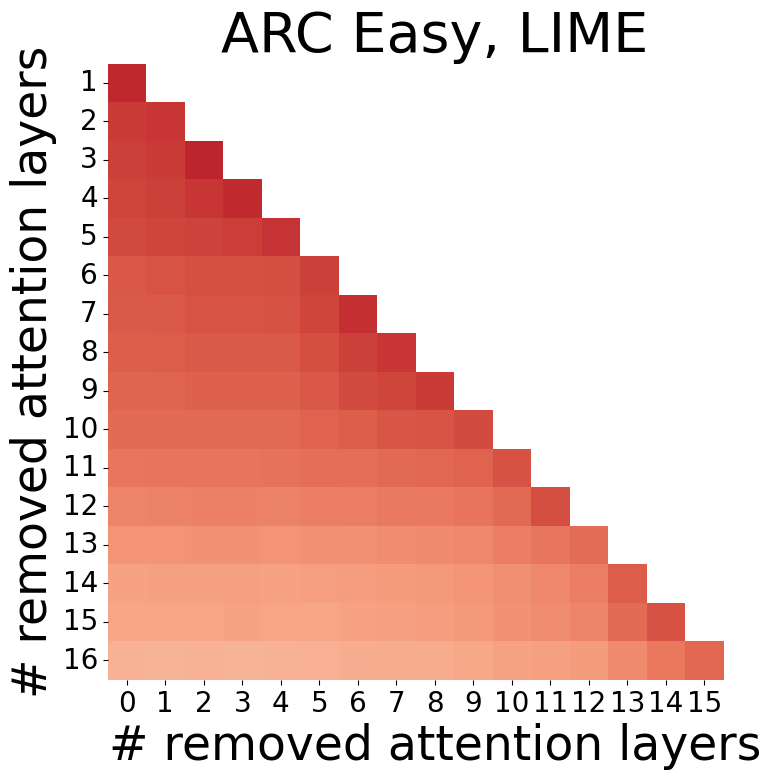

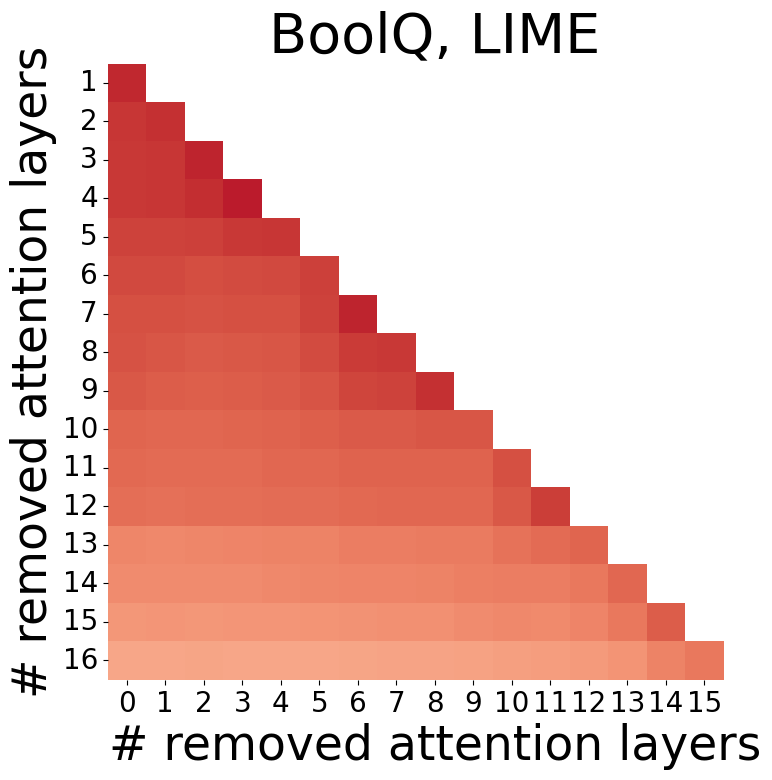

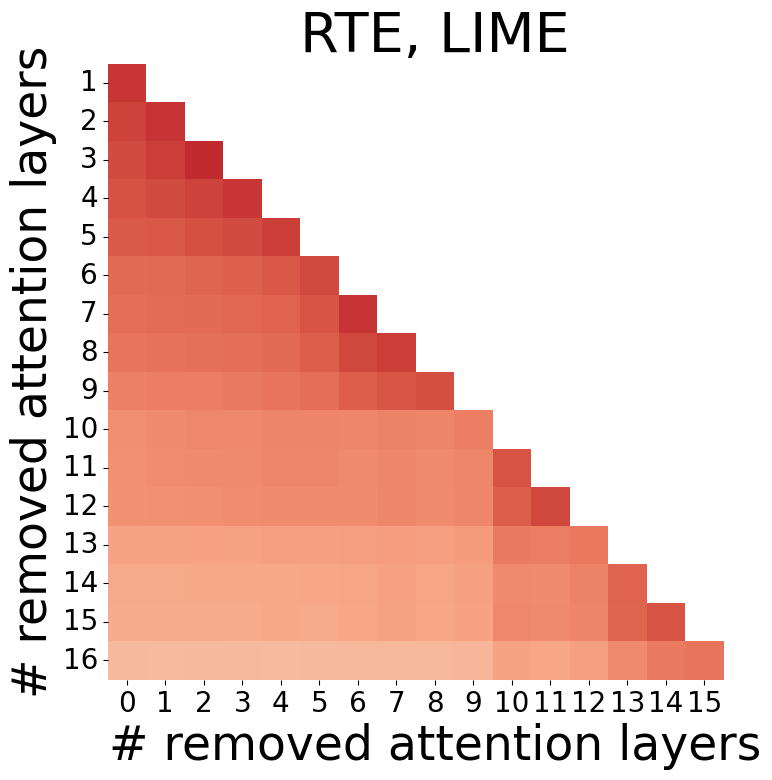

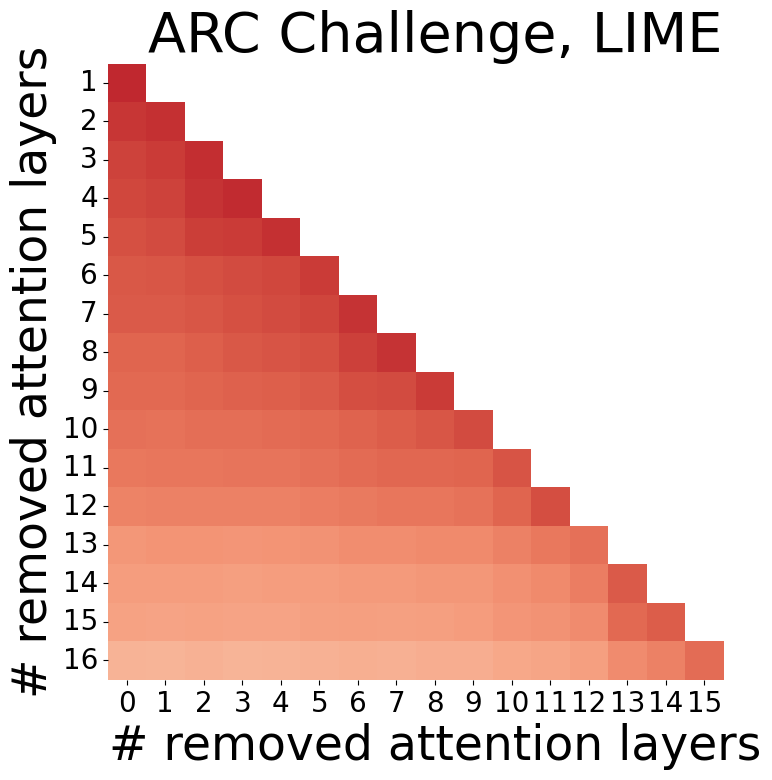

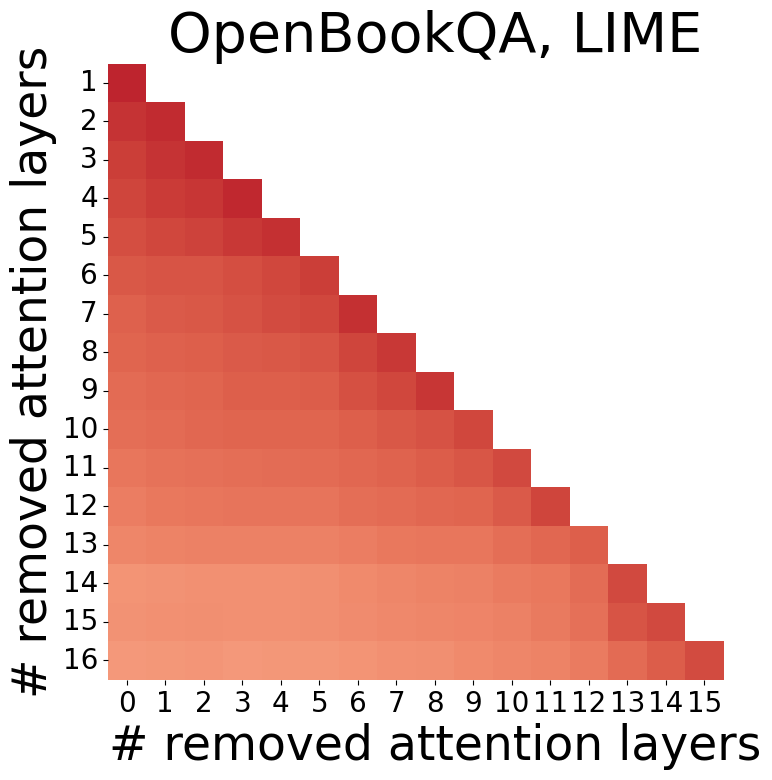

In [37]:
# Example usage
tmp_paths = ["./results/pruned/seeds/mistralai/"]
tmp_paths2 = ["./results/pruned/mistralai/"]
tmp_paths_unpruned = ["./results/unpruned/seeds/mistralai/"]
model_names = ["Mistral-7B-v0.1"]
datasets = ["arc_easy", "boolq", "rte", "arc_challenge", "openbookqa"]
fa_approach = "lime"


compute_overlap_heatmap(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)

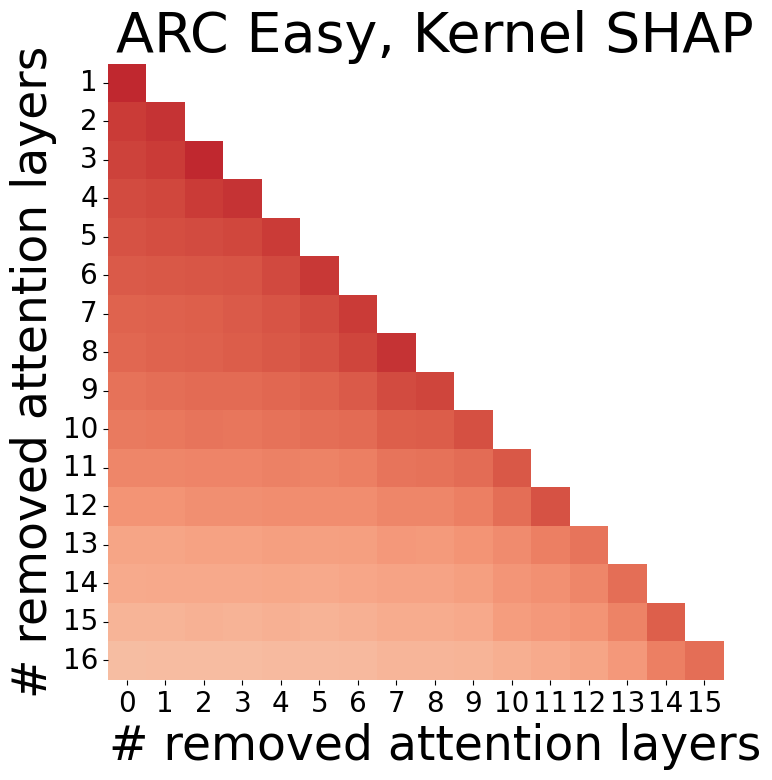

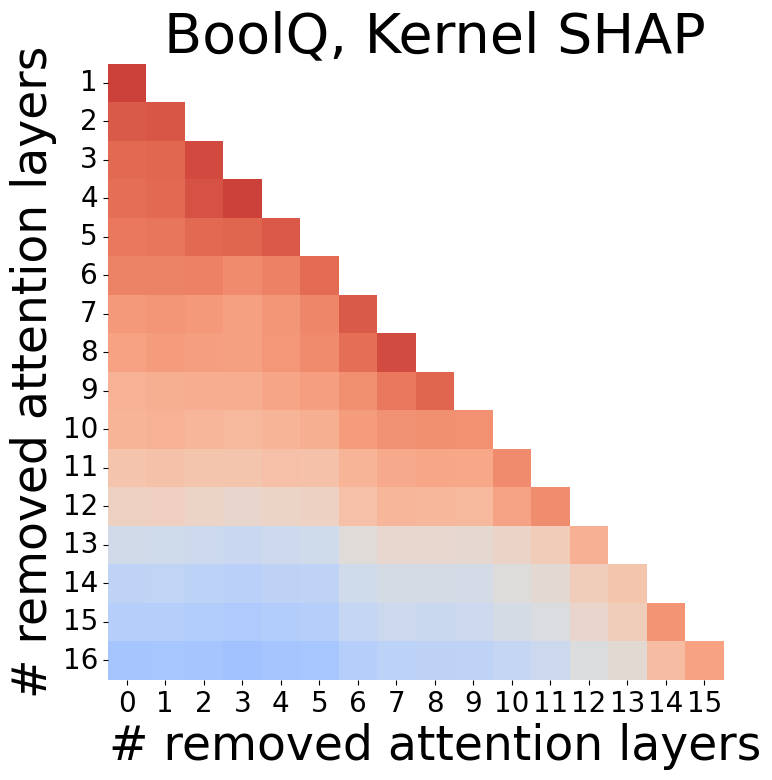

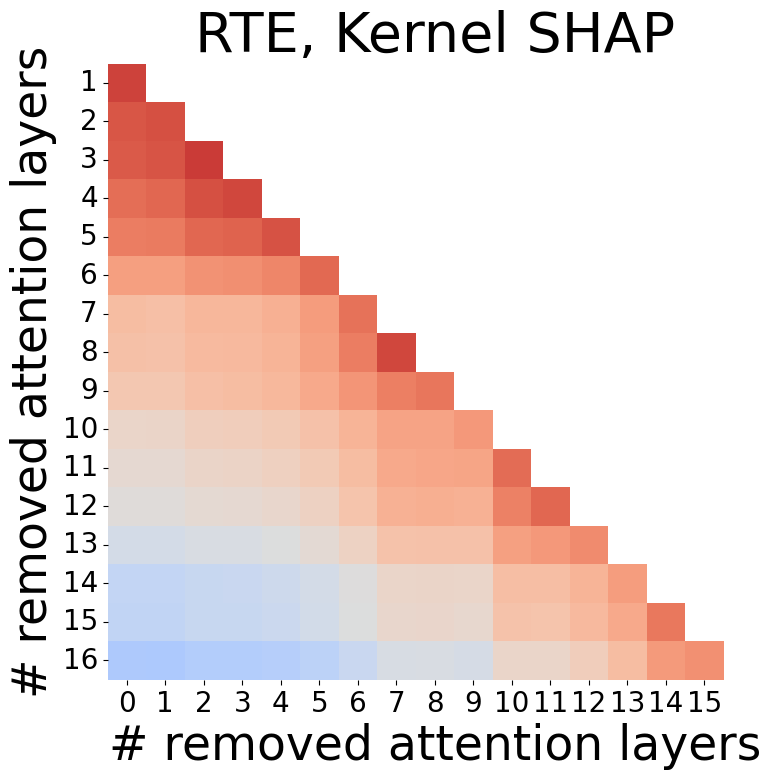

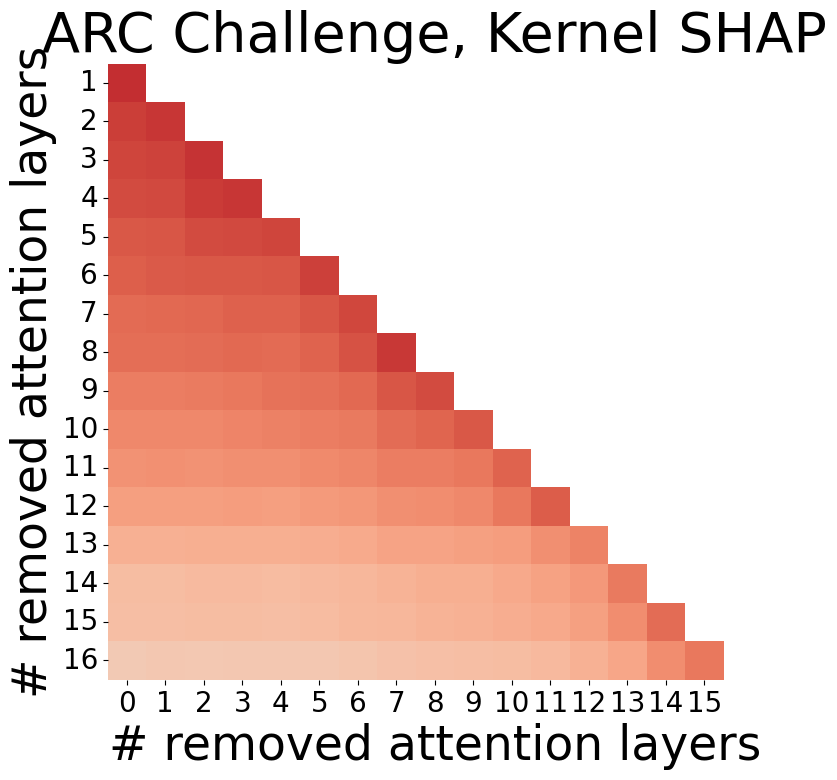

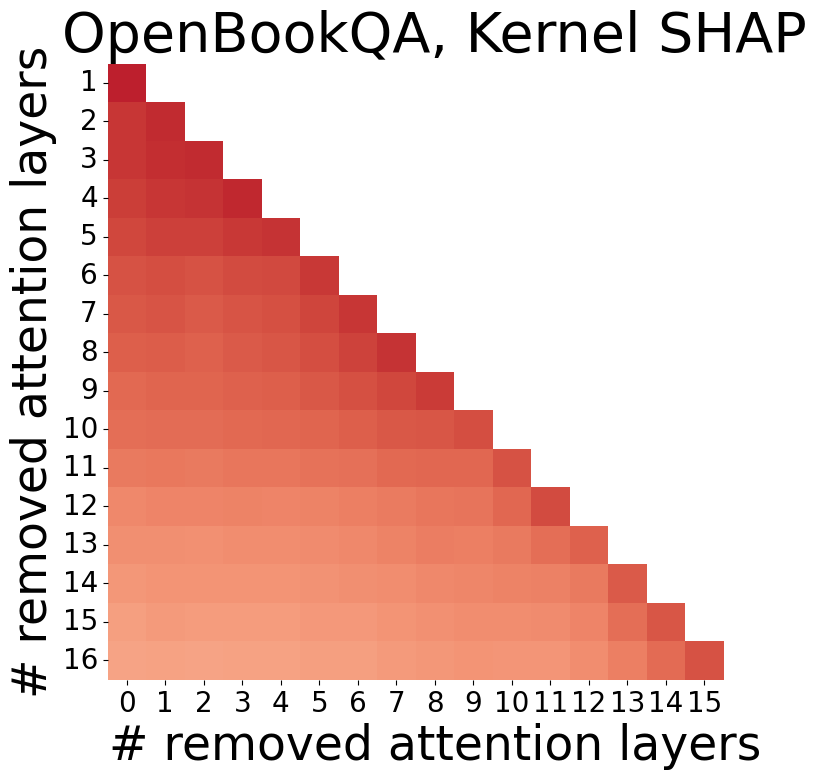

In [38]:
# Example usage
tmp_paths = ["./results/pruned/seeds/mistralai/"]
tmp_paths2 = ["./results/pruned/mistralai/"]
tmp_paths_unpruned = ["./results/unpruned/seeds/mistralai/"]
model_names = ["Mistral-7B-v0.1"]
datasets = ["arc_easy", "boolq", "rte", "arc_challenge", "openbookqa"]
fa_approach = "ks"


compute_overlap_heatmap(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)

In [ ]:
# Example usage
tmp_paths = ["./results/pruned/seeds/meta-llama/"]
tmp_paths2 = ["./results/pruned/meta-llama/"]
tmp_paths_unpruned = ["./results/unpruned/seeds/meta-llama/"]
model_names = ["Llama-2-7b-hf"]
datasets = ["arc_easy", "boolq", "rte", "arc_challenge", "openbookqa"]
fa_approach = "lime"


compute_overlap_heatmap(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)

In [ ]:
# Example usage
tmp_paths = ["./results/pruned/seeds/meta-llama/"]
tmp_paths2 = ["./results/pruned/meta-llama/"]
tmp_paths_unpruned = ["./results/unpruned/seeds/meta-llama/"]
model_names = ["Llama-2-7b-hf"]
datasets = ["arc_easy", "boolq", "rte", "arc_challenge", "openbookqa"]
fa_approach = "ks"


compute_overlap_heatmap(tmp_paths, tmp_paths2, tmp_paths_unpruned, model_names, datasets, fa_approach)